<a href="https://colab.research.google.com/github/habibasati018-debug/COCA-COLA-STOCK-ANALYSIS/blob/main/COCA_COLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING LIBRARY

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense, LSTM


IMPORTING DATA





In [ ]:
data = pd.read_csv('/content/Coca-Cola_stock_history.csv')

EXPLORARY DATA ANALYSIS(EDA)

In [ ]:
print(data.head())

       Date      Open      High       Low     Close   Volume  Dividends  \
0  1/2/1962  0.050016  0.051378  0.050016  0.050016   806400        0.0   
1  1/3/1962  0.049273  0.049273  0.048159  0.048902  1574400        0.0   
2  1/4/1962  0.049026  0.049645  0.049026  0.049273   844800        0.0   
3  1/5/1962  0.049273  0.049892  0.048035  0.048159  1420800        0.0   
4  1/8/1962  0.047787  0.047787  0.046735  0.047664  2035200        0.0   

   Stock Splits  
0             0  
1             0  
2             0  
3             0  
4             0  


In [ ]:
data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits'],
      dtype='object')

In [ ]:
data.index

RangeIndex(start=0, stop=15311, step=1)

In [ ]:
print(data.tail())

                            Date       Open       High        Low      Close  \
15306  2022-10-20 00:00:00-04:00  55.770000  55.919998  54.959999  55.080002   
15307  2022-10-21 00:00:00-04:00  55.000000  56.110001  54.990002  55.959999   
15308  2022-10-24 00:00:00-04:00  56.639999  57.730000  56.570000  57.570000   
15309  2022-10-25 00:00:00-04:00  59.040001  59.110001  57.750000  58.950001   
15310  2022-10-26 00:00:00-04:00  59.009998  59.779999  58.860001  59.389999   

         Volume  Dividends  Stock Splits  
15306  16905100        0.0             0  
15307  15028000        0.0             0  
15308  17416700        0.0             0  
15309  28829900        0.0             0  
15310  15831400        0.0             0  


In [ ]:
data.shape

(15311, 8)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15311 entries, 0 to 15310
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          15311 non-null  object 
 1   Open          15311 non-null  float64
 2   High          15311 non-null  float64
 3   Low           15311 non-null  float64
 4   Close         15311 non-null  float64
 5   Volume        15311 non-null  int64  
 6   Dividends     15311 non-null  float64
 7   Stock Splits  15311 non-null  int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 957.1+ KB


In [ ]:
null_count = data.isnull().sum()
print (null_count)

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


In [ ]:
data['Date'] = pd.to_datetime(data['Date'], format='mixed', utc=True)
data.sort_values('Date', inplace=True)
data['Date'].head()

,Date
0,1962-01-02 00:00:00+00:00
1,1962-01-03 00:00:00+00:00
2,1962-01-04 00:00:00+00:00
3,1962-01-05 00:00:00+00:00
4,1962-01-08 00:00:00+00:00


LSTM MODEL

In [ ]:
# Using the 'Close' column for prediction
pred_data = data.filter(['Close'])
dataset = data.values


In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(pred_data)

In [ ]:
# Splitting the data into training and testing sets
train_size = int(len(dataset) * 0.8)
train_data = scaled_data[0:train_size, :]
test_data = scaled_data[train_size - 60:, :]

# Preparing the data for LSTM model
def create_dataset(data, look_back=60):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 60
X_train, y_train = create_dataset(train_data, look_back)
X_test, y_test = create_dataset(test_data, look_back)


# Reshape input to be [samples, time steps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))


TRAINING AND BUILDING THE LSTM MODEL

In [ ]:
lstm_model = Sequential()
lstm_model.add(LSTM(50, return_sequences=True, input_shape=(look_back, 1)))
lstm_model.add(LSTM(50, return_sequences=False))
lstm_model.add(Dense(25))
lstm_model.add(Dense(1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lstm_predictions = lstm_model.predict(X_test)
lstm_predictions = scaler.inverse_transform(lstm_predictions)

rmse = np.sqrt(np.mean(((lstm_predictions - y_test) ** 2)))
print('LSTM Model RMSE:', rmse)


96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
LSTM Model RMSE: 1.5797782242319311


VISUALIZING THE REASULTS

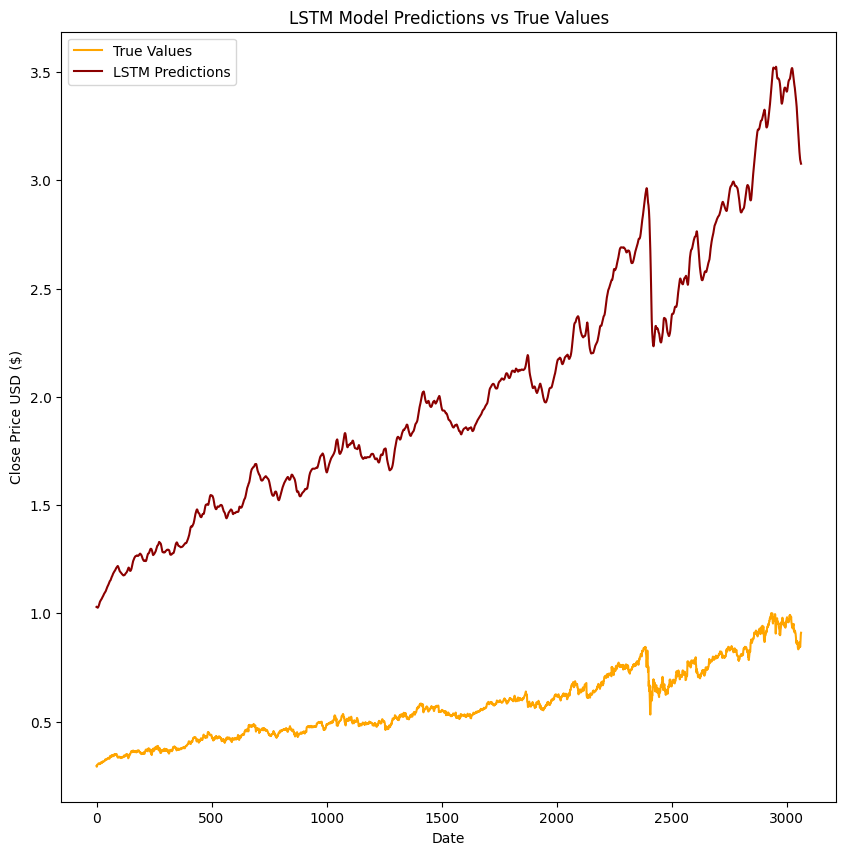

In [ ]:

plt.figure(figsize=(10,10))
plt.title('LSTM Model Predictions vs True Values')
plt.plot(y_test, label='True Values', color='orange')
plt.plot(lstm_predictions, label='LSTM Predictions', color='darkred')
plt.xlabel('Date', fontsize=10)
plt.ylabel('Close Price USD ($)', fontsize=10)
plt.legend()
plt.show()

## SVR MODEL

In [ ]:
# Preparing the data for SVR model
X = data.index.values.reshape(-1, 1)
y = data['Close'].values


# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


# Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Training the SVR Model
svr_model = SVR(kernel='rbf', C=1e3, gamma=0.1)
svr_model.fit(X_train_scaled, y_train)



SVR(C=1000.0, gamma=0.1)

VISUALIZING SVR MODEL

SVR Model RMSE: 31.388272265004193


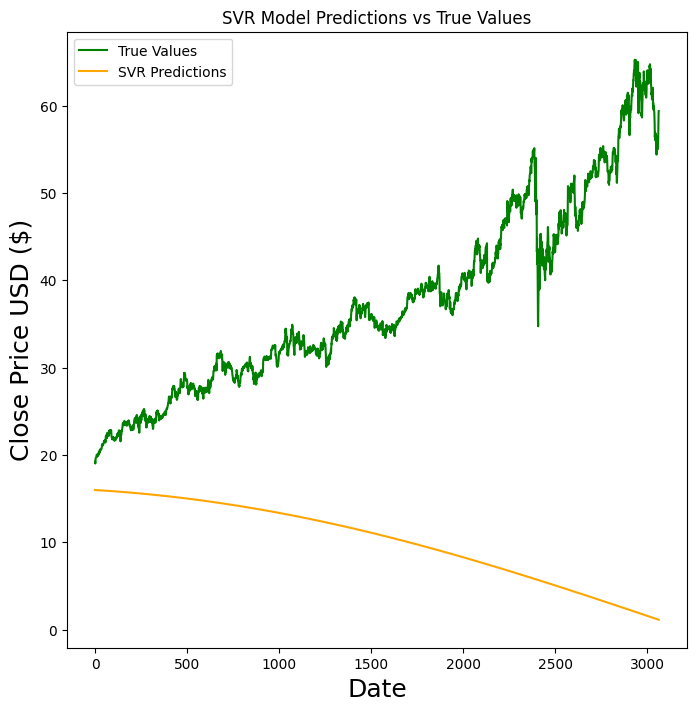

In [ ]:
# Predicting and evaluating the SVR model
svr_predictions = svr_model.predict(X_test_scaled)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_predictions))
print('SVR Model RMSE:', svr_rmse)

# Visualizing the Results for SVR
plt.figure(figsize=(8,8))
plt.title('SVR Model Predictions vs True Values')
plt.plot(y_test, label='True Values', color='green')
plt.plot(svr_predictions, label='SVR Predictions', color='orange')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.legend()
plt.show()

# SGD MODEL

In [ ]:
x =  data.index.values.reshape(-1,1)
y =  data['Close'].values


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,  shuffle=False)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
sgd_model = SGDRegressor(max_iter=1000, tol=1e-3)
sgd_model.fit(X_train_scaled, y_train)

SGDRegressor()

In [ ]:
sdg_predictions = sgd_model.predict(X_test_scaled)
sdg_rmse = np.sqrt(mean_squared_error(y_test, sdg_predictions))
print('SGD Model RMSE:', sdg_rmse)



SGD Model RMSE: 21.864026297793206


VISUALIZING SGD MODEL

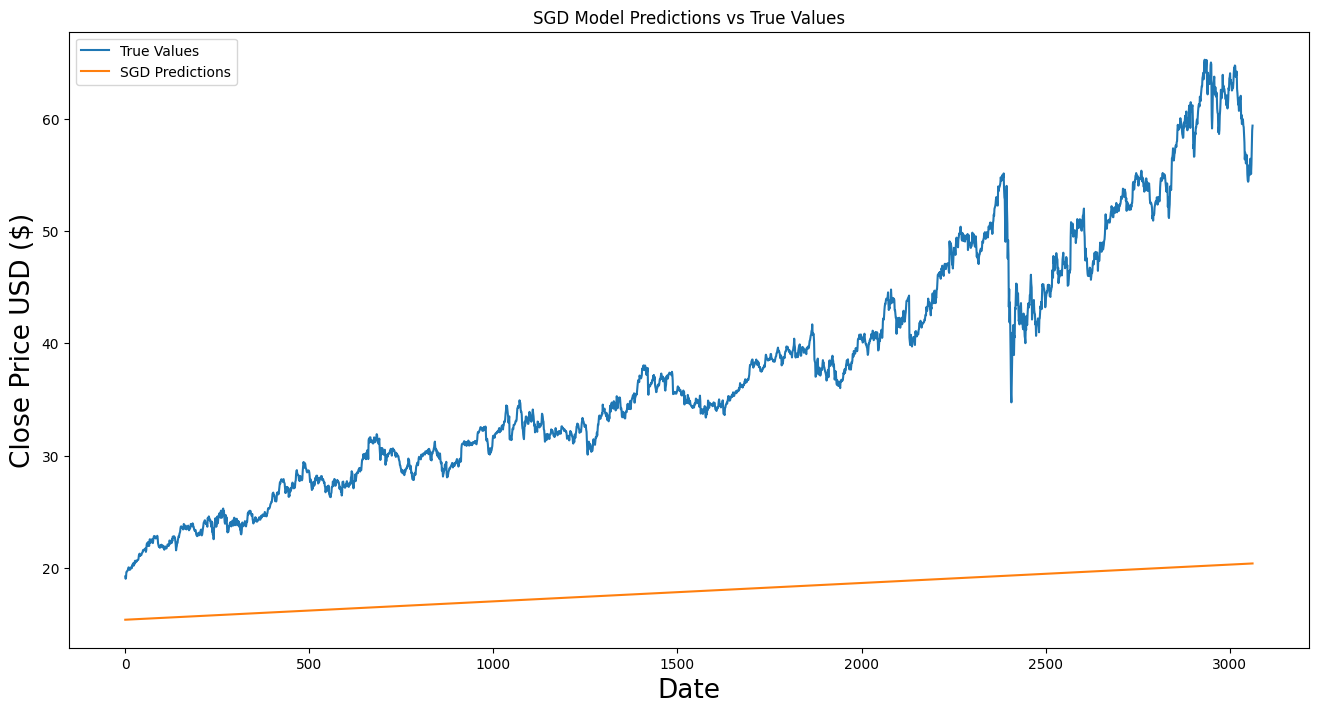

In [ ]:
plt.figure(figsize=(16,8))
plt.title('SGD Model Predictions vs True Values')
plt.plot(y_test, label='True Values')
plt.plot(sdg_predictions, label='SGD Predictions')
plt.xlabel('Date', fontsize=19)
plt.ylabel('Close Price USD ($)', fontsize=19)
plt.legend()
plt.show()

DECISION TREE REGRESSOR MODEL

In [ ]:
X = data.index.values.reshape(-1,1)
Y =  data['Close'].values

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)
dtr_model = DecisionTreeRegressor()
dtr_model.fit(X_train, y_train)

DecisionTreeRegressor()

In [ ]:
dtr_predictions = dtr_model.predict(X_test)
dtr_rmse = np.sqrt(mean_squared_error(y_test, dtr_predictions))
print('Decision Tree Model RMSE:', dtr_rmse)

Decision Tree Model RMSE: 21.608274306195128


VISIALIZING SECISION TREE MODEL

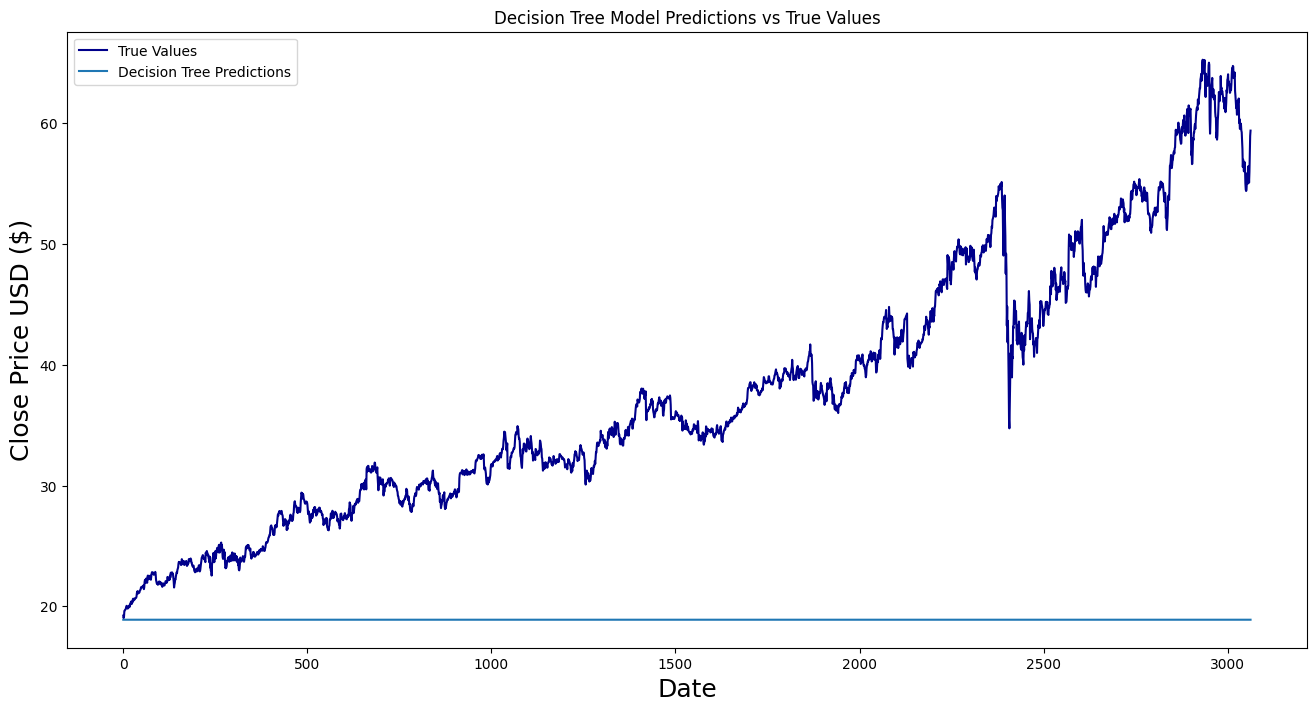

In [ ]:
plt.figure(figsize=(16,8))
plt.title('Decision Tree Model Predictions vs True Values')
plt.plot(y_test, label='True Values', color='darkblue')
plt.plot(dtr_predictions, label='Decision Tree Predictions')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.legend()
plt.show()

**RENDOM FOREST REGRESSOR MODEL**

In [ ]:
X = data.index.values.reshape(-1, 1)
y = data['Close'].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Training the Random Forest Regressor Model
rfr_model = RandomForestRegressor(n_estimators=100)
rfr_model.fit(X_train, y_train)

# Predicting with the Random Forest Model
rfr_predictions = rfr_model.predict(X_test)
rfr_rmse = np.sqrt(mean_squared_error(y_test, rfr_predictions))
print('Random Forest Model RMSE:', rfr_rmse)

Random Forest Model RMSE: 21.57018802881551


VISIALIZING RENDOM FOREST MODEL

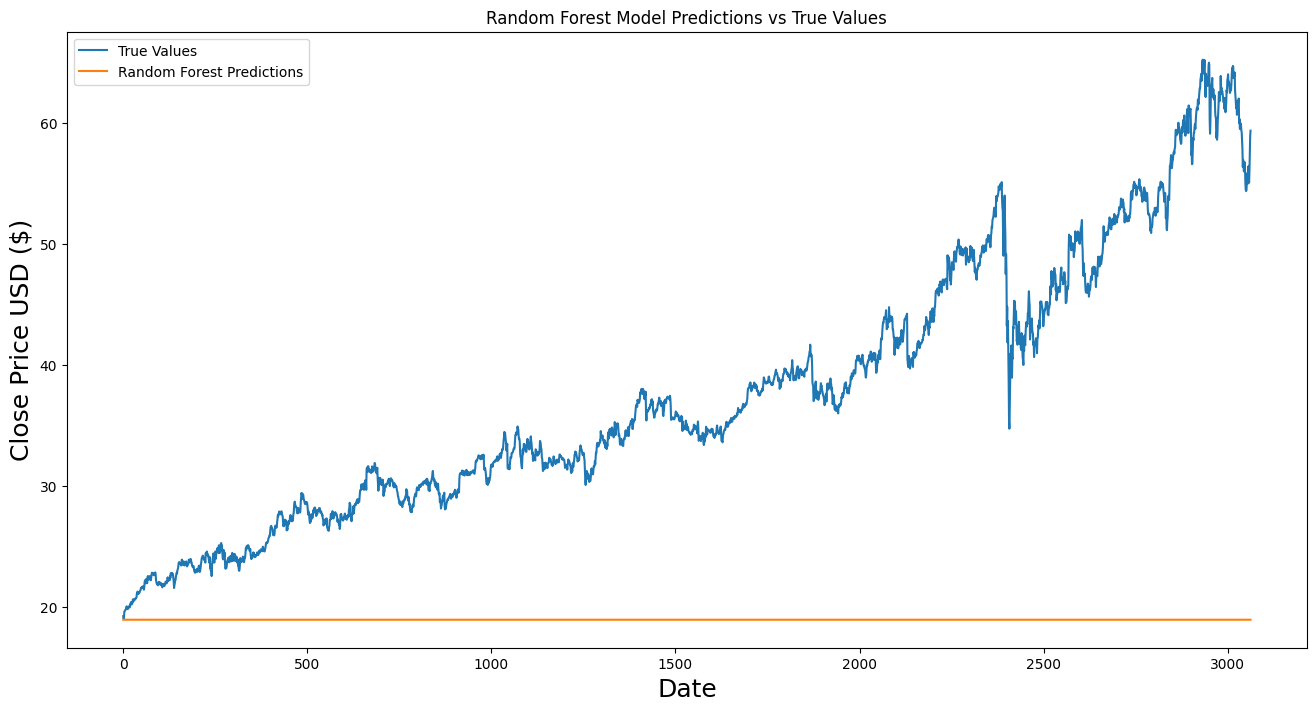

In [ ]:
plt.figure(figsize=(16,8))
plt.title('Random Forest Model Predictions vs True Values')
plt.plot(y_test, label='True Values')
plt.plot(rfr_predictions, label='Random Forest Predictions')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.legend()
plt.show()